# AI221 Project Contribution Report
| Student Name | ID | Tasks |
| :--- | :---: | :--- |
| **Ghala Alhazmi**| 4552739 | • Normalizing Data<br>• Calculating the correlation between variables<br>• Visualizing data using Scatter plot<br>• Contribution Report<br>• Code Edditing<br>• Project Presentation in PPTX       |
| **Rama Abdullah**| 4551634 | • Removing rows with missing values <br>• Calculating the variance and standard deviation  <br>• Visualizing data using histogram<br>• Code Edditing<br>• Project Presentation in PPTX       |    
| **Shatha Alharbi**| 4551038 | • Converting data types<br>• Grouping and aggregating data<br>• Visualizing data using pie chart<br>• Code Edditing<br>• Project Presentation in PPTX       |
| **Aseel Altamimi**| 4550784 | • Removing special_Character<br>• finding the median<br>• Visualizing data using pie chart<br>• Code Edditing<br>• Project Presentation in PPTX       |
| **Reman Ghawanni** | 4552530| • Validating age<br>• Finding common skills<br>• Visualizing data using Heatmap and box plot<br>• Code Edditing<br>• Project Presentation in PPTX               |

In [ ]:
'''
AI221 Group Project
section: F3
Group members Names & ID: Ghala Alhazmi 4552739 -- Rama Abdullah	4551634 -- Shatha Alharbi	4551038 -- Aseel Altamimi	4550784 -- Reman Ghawanni	4552530

The dataset includes incomplete and unclean data, including missing values, inconsistent data formats, and mixed data types.
 Therefore, we used this dataset because it is suitable for explaining data cleaning and preprocessing techniques.
'''

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
import csv
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns


In [ ]:
df=pd.read_csv('global_freelancers_raw.csv')
df.head()


,freelancer_ID,name,gender,age,country,language,primary_skill,years_of_experience,hourly_rate (USD),rating,is_active,client_satisfaction
0,FL250001,Ms. Nicole Kidd,f,52.0,Italy,Italian,Blockchain Development,11.0,100,NaN,0,NaN
1,FL250002,Vanessa Garcia,FEMALE,52.0,Australia,English,Mobile Apps,34.0,USD 100,3.3,1,84%
2,FL250003,Juan Nelson,male,53.0,Germany,German,Graphic Design,31.0,50,0.0,N,71%
3,FL250004,Amanda Spencer,F,38.0,Australia,English,Web Development,4.0,$40,1.5,N,90%
4,FL250005,Lynn Curtis DDS,female,53.0,Germany,German,Web Development,27.0,30,4.8,0,83%


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   freelancer_ID        1000 non-null   object 
 1   name                 1000 non-null   object 
 2   gender               1000 non-null   object 
 3   age                  970 non-null    float64
 4   country              1000 non-null   object 
 5   language             1000 non-null   object 
 6   primary_skill        1000 non-null   object 
 7   years_of_experience  949 non-null    float64
 8   hourly_rate (USD)    906 non-null    object 
 9   rating               899 non-null    float64
 10  is_active            911 non-null    object 
 11  client_satisfaction  824 non-null    object 
dtypes: float64(3), object(9)
memory usage: 93.9+ KB


In [ ]:
df.describe()

,age,years_of_experience,rating
count,970.000000,949.000000,899.000000
mean,40.509278,11.340358,2.512570
std,11.942605,9.680610,1.546599
min,20.000000,0.000000,0.000000
25%,31.000000,3.000000,1.400000
50%,41.000000,9.000000,2.600000
75%,51.000000,17.000000,3.800000
max,60.000000,41.000000,5.000000


In [ ]:
# class FreelancerCleaner to clean the dataset and perform analysis
class FreelancerCleaner:

    # __init__ to load the CSV file and store it in a DataFrame
    def __init__(self, file_path):
        self.file_path = file_path  # save the file path
        self.df = pd.read_csv(file_path)  # read the dataset into a DataFrame

    """**************************************  Data Processing  **************************************"""

    def cleaned_row(self, row):
        '''to check each row in the dataset whether has empty value or nan'''
        cleaned = []  # empty list to store cleaned values
        for value in row:  # loop on each value in the row

            val = str(value).strip()  # remove extra spaces
            if val != "" and val.lower() not in ["nan"]:  # check whether the value is empty or nan
                cleaned.append(value)  # append the cleaned value in the cleaned list

        return cleaned  # return the cleaned row



    def new_dataset(self):
        ''' create a clean dataset without the rows with missing values'''
        cleaned_data = []  # list to store cleaned rows

        # column names for the new dataset
        column_names = [
            "freelancer_ID",
            "name",
            "gender",
            "age",
            "country",
            "language",
            "primary_skill",
            "years_of_experience",
            "hourly_rate (USD)",
            "rating",
            "is_active",
            "client_satisfaction"
        ]


        for i in range(len(self.df)):# loop on each row in the DataFrame
            row = self.df.iloc[i]  # get the current row
            new_row = self.cleaned_row(row) # cleaning the row before adding it to the new dataset

            if len(new_row) == len(row):  # comparing both rows if lengths match this row has no missing values

                cleaned_data.append(new_row)   # append the cleaned row


        self.clean_df = pd.DataFrame(cleaned_data, columns=column_names)# convert cleaned_data into DataFrame

        print("Cleaning completed.")
        return self.clean_df  # return cleaned DataFrame

    def remove_special_Character(self):
        """Function specify to remove $ sign from the [hourly_rate] column & % sign from the ['client_satisfaction'] column"""
        def remove_special_chare(x):#function to clear any character
            return re.sub(r'[^0-9]', '',str(x))
        #mapping the function to clear any character in [hourly_rate (USD)] column
        self.clean_df['hourly_rate (USD)'] =self.clean_df['hourly_rate (USD)'].map(remove_special_chare)
        #mapping the function to clear any character in [client_satisfaction] column
        self.clean_df['client_satisfaction']=self.clean_df['client_satisfaction'].map(remove_special_chare)

    def convert_numbers(self):
          """Function converts the age and years_of_experience columns from float to int"""
          # Convert age column to integer
          self.clean_df['age'] = self.clean_df['age'].astype(int)

          # Covert years_of_exp column to integer
          self.clean_df['years_of_experience'] = self.clean_df['years_of_experience'].astype(int)

          return self.clean_df

    def validate_age(self,min_age=25, max_age=60):
        '''Function checks if age values are within the valid range (25-60)'''
        #variable contains the ages outside the range
        out_range = self.clean_df[(self.clean_df['age'] < min_age) | (self.clean_df['age'] > max_age)]
        #print the number of invalid ages
        print("Number of invalid ages:", len(out_range))
        #update the df with value in range
        self.clean_df = self.clean_df[(self.clean_df['age'] >= min_age) & (self.clean_df['age'] <= max_age)]
        print('Invalid ages daleted.')
        return self.clean_df #return df without invalid ages


    def standardize_gender(self,column_name='gender'):
       """Function standardizes the Gender column by converting values such as 'FEMALE' 'f' 'male' 'M' into consistent values either 'Female'or'Male' """
        # Loop through every cell
       for cell in self.clean_df.index:
            # read the value of each cell and remove any extra spaces
            value=str(self.clean_df.loc[cell,column_name]).strip()
            # The case where the vlaue matches the male patterns( (?i) is used so the matching is case insensitive)
            if re.fullmatch(r'(?i)male|m',value):
                value='Male'
            # The case where the vlaue matches the female patterns( (?i) is used so the matching is case insensitive)
            elif re.fullmatch(r'(?i)female|f',value):
                value='Female'
            # Assigning the formatted value back to the df
            self.clean_df.loc[cell,column_name]=value
        #return df after stanadrdizing the gender column
       return self.clean_df


    """**************************************  Data Analysis  **************************************"""


    def var_std(self):
        ''' to calculate and print the variance and standard deviation for age column'''
        print(f"Variance of age: {self.clean_df['age'].var():.2f}")# calculate the variance of age column
        print(f"Standard Deviation of age: {self.clean_df['age'].std():.2f}")# calculate the standard deviation of age column

    def common_skills(self):
        '''Function shows the top 10 most common freelancer skills and their frequency'''
        #accesses the column (primary_skill) and cleans each string by removing leading/trailing spaces, skills contain the cleaned series
        skills = self.clean_df['primary_skill'].str.strip()
        skill_counts = {} #empty dictionary to store skills count
        for skill in skills: #loop through all skills
            if skill in skill_counts: #if the skill is already in the dictionary
               skill_counts[skill] += 1 # increment its count by 1
            else: #if it's not in the dictionary
               skill_counts[skill] = 1 #add the skill to the dictionary with count 1
        #sort the skills in a dictionary by their count in descending order and take the top 10
        sorted_skills = sorted(skill_counts.items(), key=lambda x: x[1], reverse=True)[:10]
        print("Top 10 Common Skills:")
        print("_____________________")
        #loop to print each skill in the dictionary with its count
        for skill, count in sorted_skills:
             print(f"{skill:25} | {count}")# print each skill left aligned in a field of width 25, followed by its count

    def experience_per_country(self):
        """ Function calaulates average years_of_experience for each country"""
        # Group by country and get the average experience
        avg_exp = self.clean_df.groupby('country')['years_of_experience'].mean()

        print("Years Of Experience Across Countries")
        # print each country with its average value
        for country, value in avg_exp.items():
            print(f"{country:15} : {value:5.2f}")

    def Central_Tendency(self):
        """Function calculates the Central_Tendency of 'hourly_rate (USD)' & 'client_satisfaction' """
        median_1=self.clean_df['hourly_rate (USD)'].map(int).median() # calculate the median of hourly_rate column
        median_2=self.clean_df['client_satisfaction'].map(int).median() # calculate the median of client_satisfaction column
        print(f"The median of the hourly_rate {median_1:.2f}") #display the median of hourly_rate column
        print(f"The median of the client_satisfaction {median_2:.2f}") #display the median of client_satisfaction column

    def calculate_correlation(self):
        """ Function calculates the correlation between two columns(years of experience & the age of the freelancer) """
        result= self.clean_df['years_of_experience'].corr(self.clean_df['age'])
        print(f'The Correlation beteween the Years Of Experience & The Age is: {result:.2f}')


    """**************************************  Data visualization  **************************************"""

    def hist(self):
        ''' to plot histogram for the age column'''
        x = self.clean_df['age']  # select the age column
        plt.hist(x)  # plot histogram for age values
        plt.title("Age Distribution")  # add title
        plt.ylabel('Frequency')  # y-axis label
        plt.xlabel('Age')  # x-axis label
        plt.show()  # show the plot

    def heatmap(self):
        ''' Function Draws a heatmap showing correlations between numeric columns in the dataset'''
        # Compute correlation
        corr = self.clean_df.corr(numeric_only=True)
        #call sns to create a heatmap with values annotated using the coolwarm color palette
        sns.heatmap(corr, annot=True, cmap='RdBu')
        plt.title("Correlation Heatmap") #add title
        plt.show() #show the heatmaps plot

    def pie_Chart(self):
        """Functin draws a pie chart for the number of freelancers per skill"""
        # select the primary_skill column
        x = self.clean_df["primary_skill"].str.strip()
        # count how many freelancers for each skill
        y = x.value_counts()
        # draw pie chart
        plt.pie(y, labels=y.index, autopct="%1.2f%%", shadow=True)
        # add title
        plt.title("Freelancers per skill")
        # show the chart
        plt.show()

    def box_plot(self):
        ''' Function Draws a box plot showing hourly rate distribution for each skill'''
        sns.boxplot(x='primary_skill', y='hourly_rate (USD)', data=self.clean_df) #select x and y values
        plt.xticks(rotation=90) # Rotate x-axis labels for better readability
        plt.suptitle('hourly rate distribution for each skill') #add title
        plt.show() #display the plot

    def bar_Chart(self):
        """Function represnt the client_satisfaction &  country in bar chart """
        x=self.clean_df['country'].map(str) #select country column as x-axis
        y=self.clean_df['client_satisfaction'].map(int) #select client_satisfaction column as y-axis
        plt.bar(x,y,color='pink')  #create the bar_chart
        plt.xticks(rotation=90)    #Rotate x-axis labels for better readability
        plt.title("Bar_Chart")     #set title
        plt.ylabel('Hourly_rate')  #set y-label
        plt.xlabel('Gender')       #set y-label
        plt.show()                 #show the bar chart

    def scatter_plot(self):
        """Function draws the sccater plot that visualizes the years of experience across countries"""
        # initializing the data
        x = self.clean_df['country']
        y = self.clean_df['years_of_experience']

        # plotting the data
        plt.scatter(x, y)

        # Adding title to the plot
        plt.title("Years Of Experience Across Countries")

        # Adding label on the y-axis
        plt.ylabel('Years Of Experience')

        # Adding label on the x-axis
        plt.xlabel('Country')

        # Rotate x-axis so labels do not overlap
        plt.xticks(rotation=90)

         #show the scatter plot
        plt.show()




In [ ]:
"""*******************Display Data processing*******************"""

# creating the object
o = FreelancerCleaner("global_freelancers_raw.csv")
# get the cleaned dataset
cleaned_df = o.new_dataset()
# call convert_numbers method
o.convert_numbers()
# call removing special Character
o.remove_special_Character()
# call validate_age method
o.validate_age()
# call standardize_gender method
o.standardize_gender()

Cleaning completed.
Number of invalid ages: 77
Invalid ages daleted.


,freelancer_ID,name,gender,age,country,language,primary_skill,years_of_experience,hourly_rate (USD),rating,is_active,client_satisfaction
0,FL250002,Vanessa Garcia,Female,52,Australia,English,Mobile Apps,34,100,3.3,1,84
1,FL250003,Juan Nelson,Male,53,Germany,German,Graphic Design,31,50,0.0,N,71
2,FL250004,Amanda Spencer,Female,38,Australia,English,Web Development,4,40,1.5,N,90
3,FL250005,Lynn Curtis DDS,Female,53,Germany,German,Web Development,27,30,4.8,0,83
4,FL250007,Eric Myers,Male,52,Indonesia,Indonesian,Data Analysis,10,75,3.1,0,94
...,...,...,...,...,...,...,...,...,...,...,...,...
548,FL250995,Jennifer Hinton,Female,34,South Africa,Afrikaans,DevOps,8,30,3.9,Y,95
549,FL250996,Albert Wilcox,Male,56,Turkey,Turkish,DevOps,13,100,0.0,no,68
550,FL250997,Cheryl Norris,Female,26,Germany,German,Blockchain Development,6,40,2.8,N,82
551,FL250999,John Obrien,Male,46,Russia,Russian,Machine Learning,22,100,2.8,yes,97


In [ ]:
"""*******************Display Data analysis*******************"""
# call var_std method
o.var_std()
# call callcalculate_Central_Tendency method
o.Central_Tendency()
# call callcalculate_correlation method
o.calculate_correlation()
# call common_skills method
o.common_skills()
# call experience_per_country method
o.experience_per_country()


Variance of age: 103.69
Standard Deviation of age: 10.18
The median of the hourly_rate 50.00
The median of the client_satisfaction 78.00
The Correlation beteween the Years Of Experience & The Age is: 0.52
Top 10 Common Skills:
_____________________
UI/UX Design              | 58
Web Development           | 56
Data Analysis             | 51
DevOps                    | 49
Mobile Apps               | 47
Blockchain Development    | 46
Machine Learning          | 46
Graphic Design            | 43
Cybersecurity             | 43
AI                        | 37
Years Of Experience Across Countries
Argentina       :  9.42
Australia       : 10.74
Brazil          : 12.77
Canada          : 13.15
China           : 11.86
Egypt           : 10.95
France          : 12.74
Germany         : 12.72
India           : 12.89
Indonesia       : 15.50
Italy           : 14.89
Japan           : 11.89
Mexico          : 14.96
Netherlands     : 12.90
Russia          : 11.55
South Africa    : 14.00
South Korea     : 13

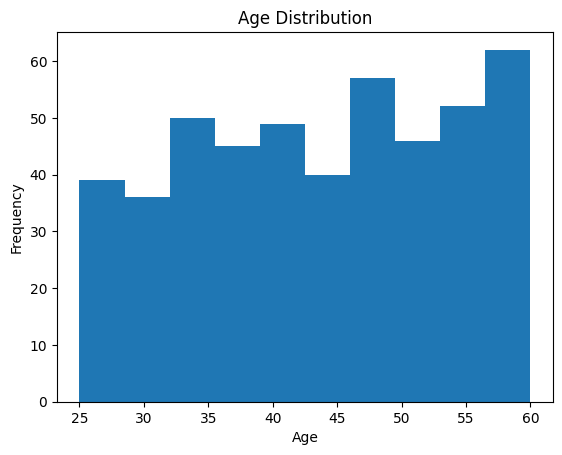

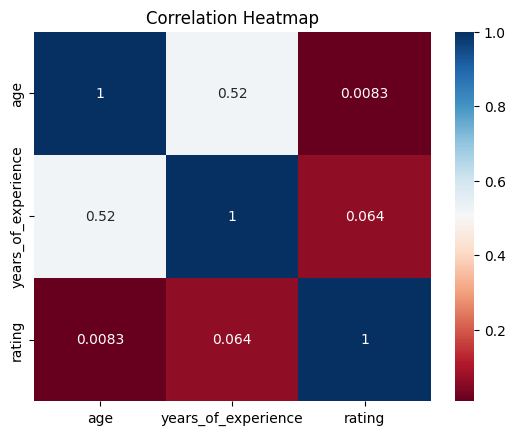

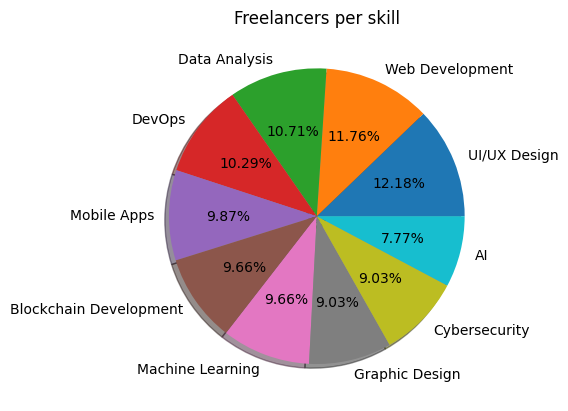

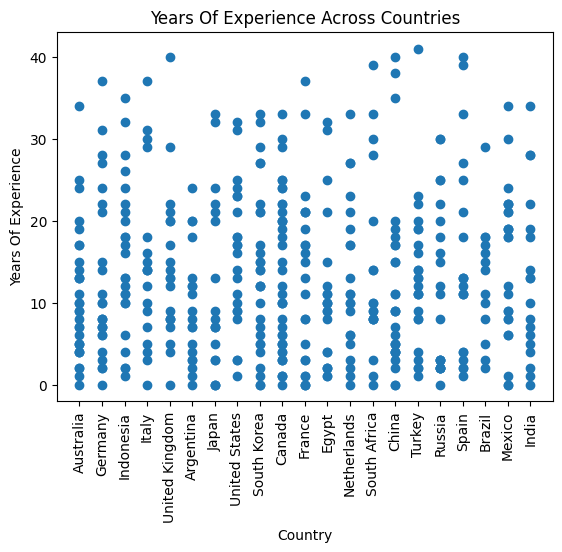

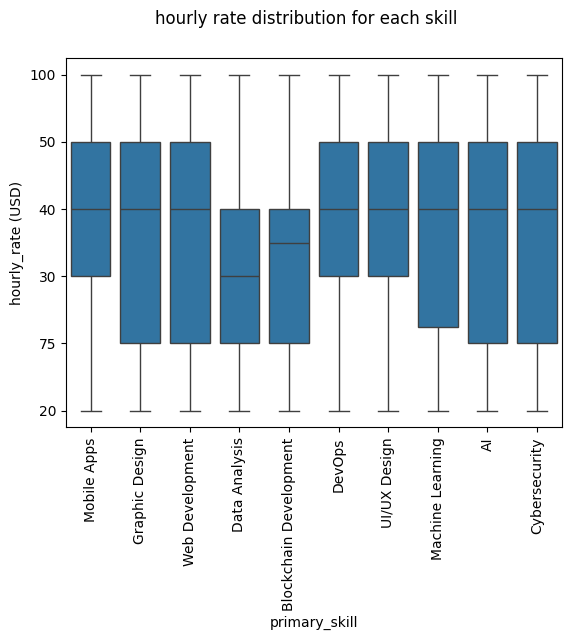

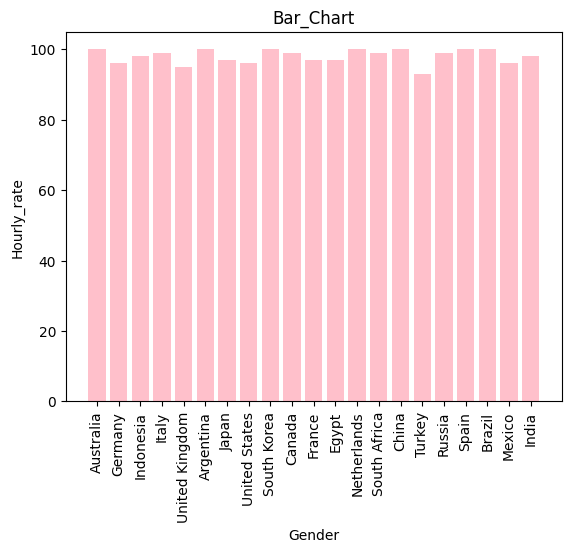

In [ ]:
"""*******************Display Data visualization*******************"""
# call hist method
o.hist()
# call heatmap method
o.heatmap()
# call pie_Chart method
o.pie_Chart()
# call scatter_plot method
o.scatter_plot()
# call box_plot method
o.box_plot()
# call bar_chart method
o.bar_Chart()

In [ ]:
o.clean_df.head()

,freelancer_ID,name,gender,age,country,language,primary_skill,years_of_experience,hourly_rate (USD),rating,is_active,client_satisfaction
0,FL250002,Vanessa Garcia,Female,52,Australia,English,Mobile Apps,34,100,3.3,1,84
1,FL250003,Juan Nelson,Male,53,Germany,German,Graphic Design,31,50,0.0,N,71
2,FL250004,Amanda Spencer,Female,38,Australia,English,Web Development,4,40,1.5,N,90
3,FL250005,Lynn Curtis DDS,Female,53,Germany,German,Web Development,27,30,4.8,0,83
4,FL250007,Eric Myers,Male,52,Indonesia,Indonesian,Data Analysis,10,75,3.1,0,94
